In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [ ]:
df = pd.read_csv('customer_churn_dataset.csv.csv')

In [ ]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163284 entries, 0 to 163283
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         163284 non-null  int64  
 1   Age                163283 non-null  float64
 2   Gender             163283 non-null  object 
 3   Tenure             163283 non-null  float64
 4   Usage Frequency    163283 non-null  float64
 5   Support Calls      163283 non-null  float64
 6   Payment Delay      163283 non-null  float64
 7   Subscription Type  163283 non-null  object 
 8   Contract Length    163283 non-null  object 
 9   Total Spend        163283 non-null  float64
 10  Last Interaction   163283 non-null  float64
 11  Churn              163283 non-null  float64
dtypes: float64(8), int64(1), object(3)
memory usage: 14.9+ MB


In [ ]:
df.isna().sum()

,0
CustomerID,0
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [ ]:


# 2. Separate numerical and categorical columns
# (Median can only be calculated for numerical columns)
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(exclude=['number']).columns

# 3. Replace missing values in numeric columns with the median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# 4. Replace missing values in categorical columns with the mode
# (Since "median" of categories like 'Gender' doesn't exist)
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 5. Verify that no missing values remain
print(df.isnull().sum())

# 6. Save the cleaned dataset
df.to_csv('customer_churn_cleaned.csv', index=False)

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [ ]:
df_clean = df.drop('CustomerID', axis=1).dropna()

In [ ]:
df_clean = df.drop('CustomerID', axis=1).dropna()

In [ ]:
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

In [ ]:
le = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col].astype(str))

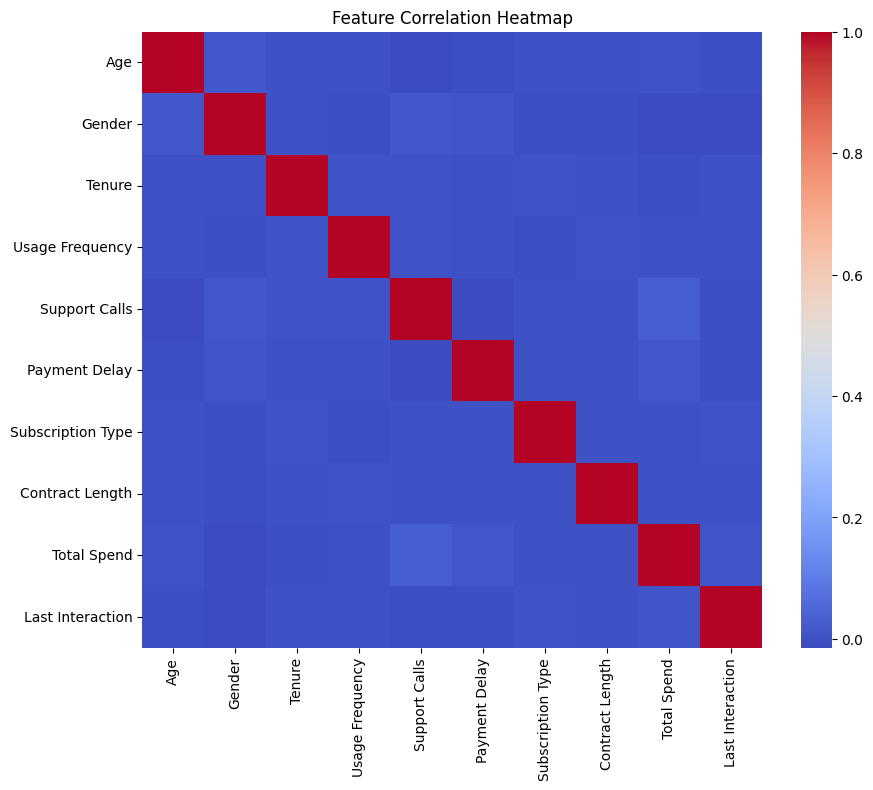

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

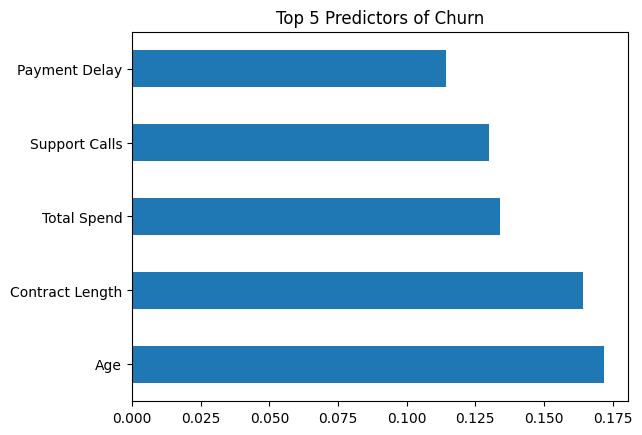

In [ ]:
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(5).plot(kind='barh')
plt.title('Top 5 Predictors of Churn')
plt.show()

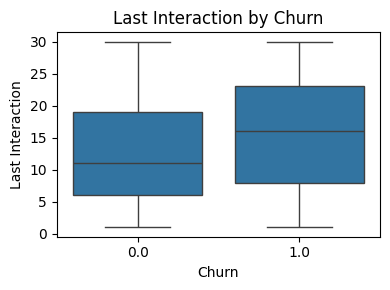

In [ ]:
plt.figure(figsize=(4,3))
sns.boxplot(x='Churn', y='Last Interaction', data=df)
plt.title("Last Interaction by Churn")
plt.tight_layout()
plt.savefig("last_interaction_vs_churn.png", dpi=100)
plt.show()

/tmp/ipykernel_1031/860322348.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Support Calls', data=df, palette='husl').set_title('Calls vs Churn')


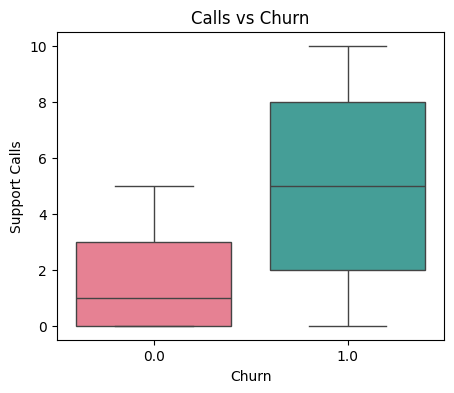

In [ ]:
# Viz 5: Support Calls Insight
plt.figure(figsize=(5,4))
sns.boxplot(x='Churn', y='Support Calls', data=df, palette='husl').set_title('Calls vs Churn')
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]):.2f}")

              precision    recall  f1-score   support

         0.0       1.00      0.87      0.93       415
         1.0       1.00      1.00      1.00     32242

    accuracy                           1.00     32657
   macro avg       1.00      0.93      0.96     32657
weighted avg       1.00      1.00      1.00     32657

ROC-AUC Score: 1.00
